In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [3]:
df = pd.read_csv('synthetic_real_estate_data.xls')

In [11]:
df

,Area_sqft,Bedrooms,Bathrooms,Age,Distance_to_CityCenter_km,Price
0,1748.357077,1,1,43,11.268221,74482.867074
1,1430.867849,2,1,39,8.342830,93659.178143
2,1823.844269,1,2,29,4.716948,178618.576486
3,2261.514928,4,3,77,2.370470,270714.953574
4,1382.923313,3,1,73,9.358360,71641.465903
...,...,...,...,...,...,...
19995,1693.913671,5,2,81,19.616373,-17141.465026
19996,2188.683289,3,2,79,16.498174,101383.061057
19997,1689.176985,3,2,20,13.359658,98808.483911
19998,2356.764865,4,3,54,7.528748,296513.503636


In [4]:
df.head()

,Area_sqft,Bedrooms,Bathrooms,Age,Distance_to_CityCenter_km,Price
0,1748.357077,1,1,43,11.268221,74482.867074
1,1430.867849,2,1,39,8.342830,93659.178143
2,1823.844269,1,2,29,4.716948,178618.576486
3,2261.514928,4,3,77,2.370470,270714.953574
4,1382.923313,3,1,73,9.358360,71641.465903


In [5]:
df.isnull().sum()

Area_sqft                    0
Bedrooms                     0
Bathrooms                    0
Age                          0
Distance_to_CityCenter_km    0
Price                        0
dtype: int64

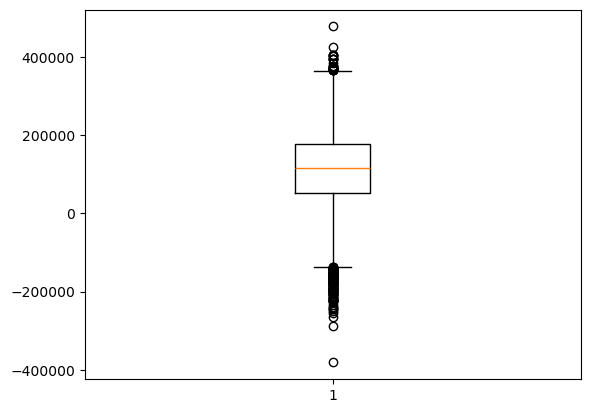

In [6]:
plt.boxplot(df['Price'])
plt.show()

In [7]:
o1 = df[(df['Price'] <= 400000) & (df['Price'] >=0)]

In [17]:
o1

,Area_sqft,Bedrooms,Bathrooms,Age,Distance_to_CityCenter_km,Price
0,1748.357077,1,1,43,11.268221,74482.867074
1,1430.867849,2,1,39,8.342830,93659.178143
2,1823.844269,1,2,29,4.716948,178618.576486
3,2261.514928,4,3,77,2.370470,270714.953574
4,1382.923313,3,1,73,9.358360,71641.465903
...,...,...,...,...,...,...
19993,1951.245828,5,2,90,16.924913,105603.662909
19994,1976.295254,2,1,91,5.027319,181811.931024
19996,2188.683289,3,2,79,16.498174,101383.061057
19997,1689.176985,3,2,20,13.359658,98808.483911


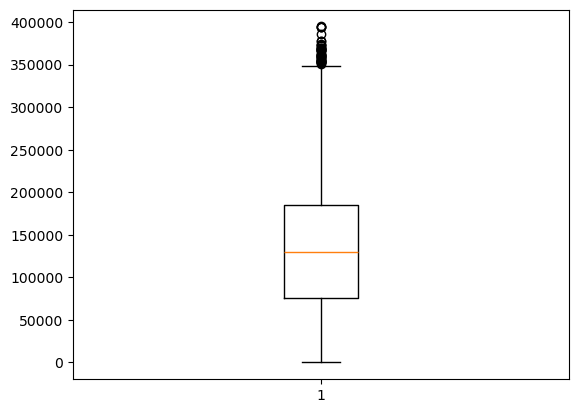

In [9]:
plt.boxplot(o1['Price'])
plt.show()

In [10]:
o1.duplicated().sum()

np.int64(0)

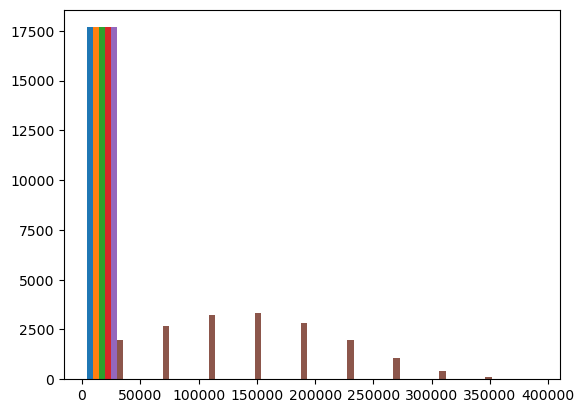

In [20]:
plt.hist(o1)
plt.show()

C:\Users\mafin\AppData\Local\Temp\ipykernel_10380\520283737.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  o1['Bed_Bath'] = o1['Bedrooms'].astype(str) + '-' + o1['Bathrooms'].astype(str)


<Axes: xlabel='Bed_Bath', ylabel='count'>

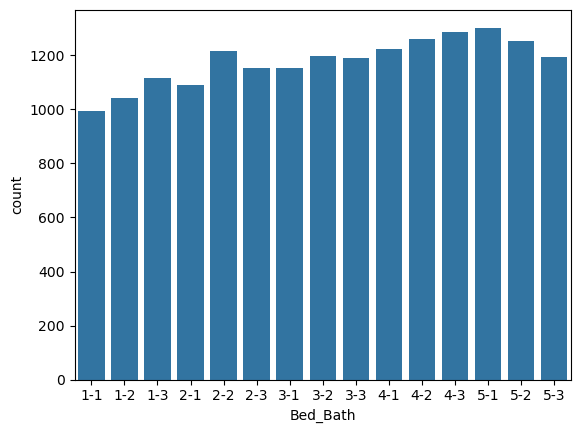

In [26]:
o1['Bed_Bath'] = o1['Bedrooms'].astype(str) + '-' + o1['Bathrooms'].astype(str)
sns.countplot(x='Bed_Bath', data=o1, order=sorted(o1['Bed_Bath'].unique()))


In [27]:
o1

,Area_sqft,Bedrooms,Bathrooms,Age,Distance_to_CityCenter_km,Price,Bed_Bath
0,1748.357077,1,1,43,11.268221,74482.867074,1-1
1,1430.867849,2,1,39,8.342830,93659.178143,2-1
2,1823.844269,1,2,29,4.716948,178618.576486,1-2
3,2261.514928,4,3,77,2.370470,270714.953574,4-3
4,1382.923313,3,1,73,9.358360,71641.465903,3-1
...,...,...,...,...,...,...,...
19993,1951.245828,5,2,90,16.924913,105603.662909,5-2
19994,1976.295254,2,1,91,5.027319,181811.931024,2-1
19996,2188.683289,3,2,79,16.498174,101383.061057,3-2
19997,1689.176985,3,2,20,13.359658,98808.483911,3-2


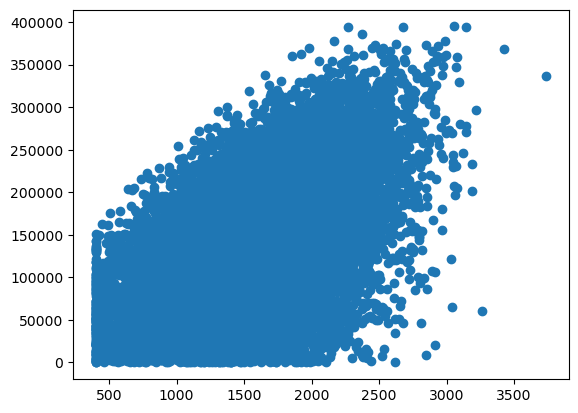

In [29]:
plt.scatter(x=o1['Area_sqft'],y=o1['Price'])
plt.show()

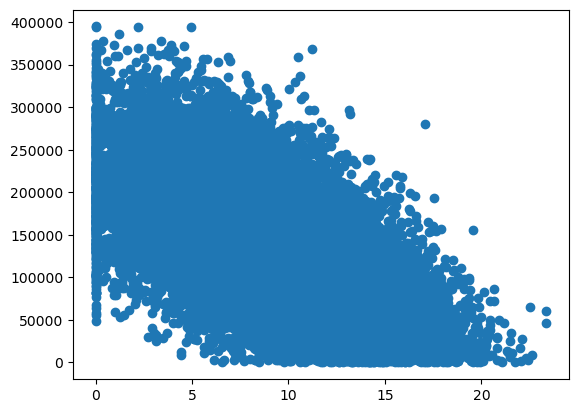

In [30]:
plt.scatter(x=o1['Distance_to_CityCenter_km'],y=o1['Price'])
plt.show()

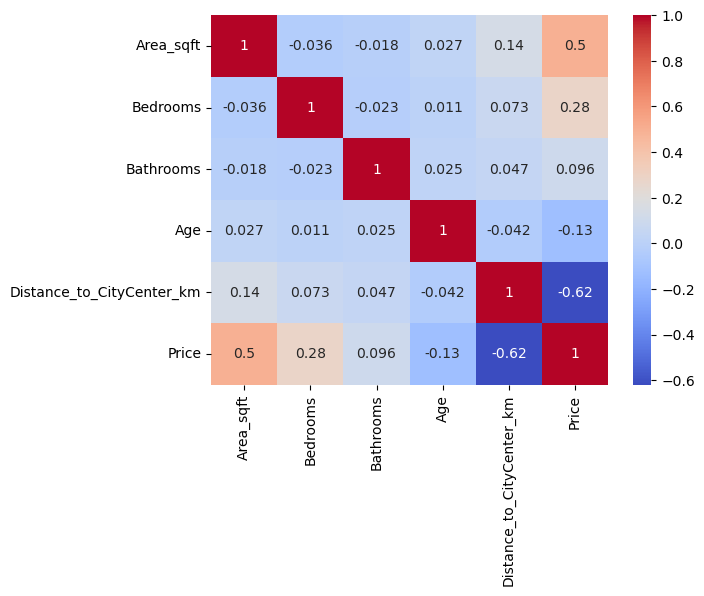

In [60]:
corr_matrix = o1.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

In [33]:
o1.dtypes

Area_sqft                    float64
Bedrooms                       int64
Bathrooms                      int64
Age                            int64
Distance_to_CityCenter_km    float64
Price                        float64
Bed_Bath                      object
dtype: object

In [34]:
# Split Bed_Bath into two numeric columns
o1[['Bedrooms_numeric', 'Bathrooms_numeric']] = o1['Bed_Bath'].str.split('-', expand=True).astype(int)

C:\Users\mafin\AppData\Local\Temp\ipykernel_10380\2054907064.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  o1[['Bedrooms_numeric', 'Bathrooms_numeric']] = o1['Bed_Bath'].str.split('-', expand=True).astype(int)
C:\Users\mafin\AppData\Local\Temp\ipykernel_10380\2054907064.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  o1[['Bedrooms_numeric', 'Bathrooms_numeric']] = o1['Bed_Bath'].str.split('-', expand=True).astype(int)


In [35]:
o1

,Area_sqft,Bedrooms,Bathrooms,Age,Distance_to_CityCenter_km,Price,Bed_Bath,Bedrooms_numeric,Bathrooms_numeric
0,1748.357077,1,1,43,11.268221,74482.867074,1-1,1,1
1,1430.867849,2,1,39,8.342830,93659.178143,2-1,2,1
2,1823.844269,1,2,29,4.716948,178618.576486,1-2,1,2
3,2261.514928,4,3,77,2.370470,270714.953574,4-3,4,3
4,1382.923313,3,1,73,9.358360,71641.465903,3-1,3,1
...,...,...,...,...,...,...,...,...,...
19993,1951.245828,5,2,90,16.924913,105603.662909,5-2,5,2
19994,1976.295254,2,1,91,5.027319,181811.931024,2-1,2,1
19996,2188.683289,3,2,79,16.498174,101383.061057,3-2,3,2
19997,1689.176985,3,2,20,13.359658,98808.483911,3-2,3,2


In [36]:
o1['Bed_Bath'].drop

<bound method Series.drop of 0        1-1
1        2-1
2        1-2
3        4-3
4        3-1
        ... 
19993    5-2
19994    2-1
19996    3-2
19997    3-2
19998    4-3
Name: Bed_Bath, Length: 17678, dtype: object>

In [38]:
o1 = o1.drop(['Bed_Bath'],axis=1)

In [40]:
o1["New_Price"] = o1['Price']

In [44]:
o1 = o1.drop(['Price'],axis=1)

In [44]:
x = o1.iloc[::,:5]
x

,Area_sqft,Bedrooms,Bathrooms,Age,Distance_to_CityCenter_km
0,1748.357077,1,1,43,11.268221
1,1430.867849,2,1,39,8.342830
2,1823.844269,1,2,29,4.716948
3,2261.514928,4,3,77,2.370470
4,1382.923313,3,1,73,9.358360
...,...,...,...,...,...
19993,1951.245828,5,2,90,16.924913
19994,1976.295254,2,1,91,5.027319
19996,2188.683289,3,2,79,16.498174
19997,1689.176985,3,2,20,13.359658


In [54]:
x_tain

array([[1.74835708e+03, 1.00000000e+00, 1.00000000e+00, ...,
        1.12682213e+01, 1.00000000e+00, 1.00000000e+00],
       [1.43086785e+03, 2.00000000e+00, 1.00000000e+00, ...,
        8.34283026e+00, 2.00000000e+00, 1.00000000e+00],
       [1.82384427e+03, 1.00000000e+00, 2.00000000e+00, ...,
        4.71694769e+00, 1.00000000e+00, 2.00000000e+00],
       ...,
       [2.18868329e+03, 3.00000000e+00, 2.00000000e+00, ...,
        1.64981744e+01, 3.00000000e+00, 2.00000000e+00],
       [1.68917698e+03, 3.00000000e+00, 2.00000000e+00, ...,
        1.33596580e+01, 3.00000000e+00, 2.00000000e+00],
       [2.35676486e+03, 4.00000000e+00, 3.00000000e+00, ...,
        7.52874819e+00, 4.00000000e+00, 3.00000000e+00]])

In [56]:
y = o1.iloc[::,-1]
u = o1.loc[::,'Price']


0         74482.867074
1         93659.178143
2        178618.576486
3        270714.953574
4         71641.465903
             ...      
19993    105603.662909
19994    181811.931024
19996    101383.061057
19997     98808.483911
19998    296513.503636
Name: Price, Length: 17678, dtype: float64

In [16]:
o1

,Area_sqft,Bedrooms,Bathrooms,Age,Distance_to_CityCenter_km,Price
0,1748.357077,1,1,43,11.268221,74482.867074
1,1430.867849,2,1,39,8.342830,93659.178143
2,1823.844269,1,2,29,4.716948,178618.576486
3,2261.514928,4,3,77,2.370470,270714.953574
4,1382.923313,3,1,73,9.358360,71641.465903
...,...,...,...,...,...,...
19993,1951.245828,5,2,90,16.924913,105603.662909
19994,1976.295254,2,1,91,5.027319,181811.931024
19996,2188.683289,3,2,79,16.498174,101383.061057
19997,1689.176985,3,2,20,13.359658,98808.483911


In [46]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [47]:
x_train

,Area_sqft,Bedrooms,Bathrooms,Age,Distance_to_CityCenter_km
7091,2338.557935,2,3,20,12.078609
11889,1142.667942,4,1,37,10.524175
1270,2045.655060,1,3,62,3.385270
16071,805.853784,5,3,12,10.337349
9947,1192.980919,5,3,64,10.368379
...,...,...,...,...,...
4149,1621.765102,2,1,2,11.827458
16460,1379.895564,4,2,2,1.523649
6092,1418.648149,5,1,1,7.006560
6484,1851.570099,4,1,72,18.565967


In [48]:
y_test

13020      8224.411044
9518     170583.658527
15929     91142.989863
13282     95305.400031
15456     44328.228542
             ...      
13925    147135.469914
9936     174246.200918
6427      96806.637579
8516     153107.029521
18049    243916.693866
Name: Price, Length: 3536, dtype: float64

In [49]:
lr = LinearRegression()

In [50]:
lr.fit(x_train,y_train)

LinearRegression()

In [74]:
predictive_data = lr.predict(x_test)

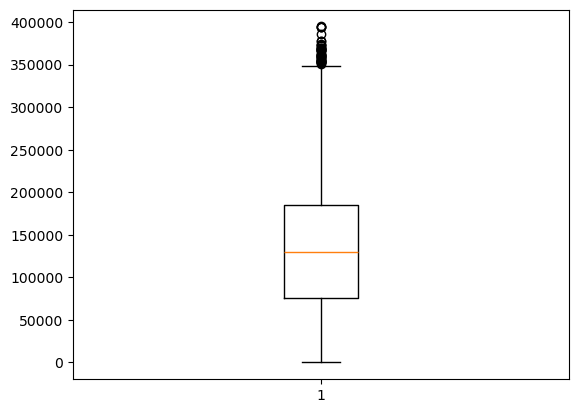

In [57]:
plt.boxplot(o1['Price'])
plt.show()

In [52]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

In [75]:
r2_score(y_test ,predictive_data)

0.9174611665476282

In [33]:
o1

,Area_sqft,Bedrooms,Bathrooms,Age,Distance_to_CityCenter_km,Price
0,1748.357077,1,1,43,11.268221,74482.867074
1,1430.867849,2,1,39,8.342830,93659.178143
2,1823.844269,1,2,29,4.716948,178618.576486
3,2261.514928,4,3,77,2.370470,270714.953574
4,1382.923313,3,1,73,9.358360,71641.465903
...,...,...,...,...,...,...
19993,1951.245828,5,2,90,16.924913,105603.662909
19994,1976.295254,2,1,91,5.027319,181811.931024
19996,2188.683289,3,2,79,16.498174,101383.061057
19997,1689.176985,3,2,20,13.359658,98808.483911


In [54]:
new_house = np.array([[1748.357077, 1, 1, 43, 11.268221]])
predicted_price = lr.predict(new_house)
print(predicted_price[0])

73122.81019617451


C:\Users\mafin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [87]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(x_train)

lin2 = LinearRegression()
lin2.fit(X_train_poly, y_train)

# Transform test set and predict
X_test_poly = poly.transform(x_test)
y_pred_poly = lin2.predict(X_test_poly)

# R² score
score = r2_score(y_test, y_pred_poly)
print("R² score:", score)

R² score: 0.9304335150686591


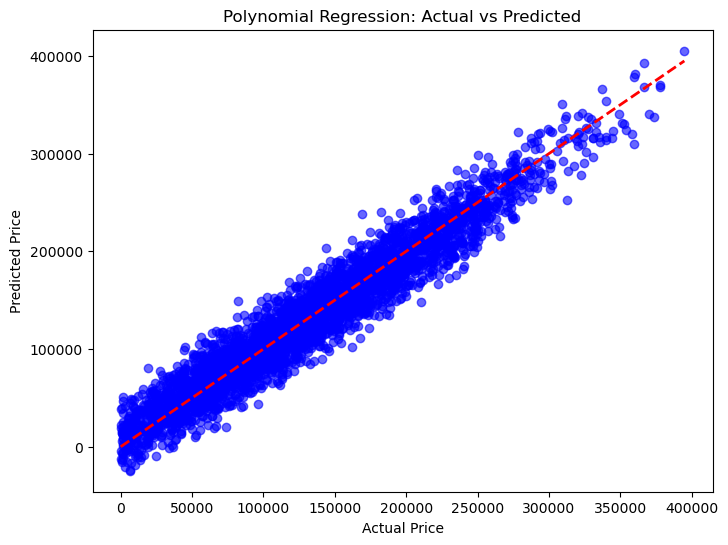

In [89]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_poly, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Polynomial Regression: Actual vs Predicted")
plt.show()

In [94]:
import pickle

In [95]:
filename = 'Project_Predictive_Modeling_for_Real_Estate_Pricing_predection.pkl'

In [96]:
with open(filename, 'wb') as file:
    pickle.dump(lr, file)


In [97]:
import pickle

with open("polynomial_model.pkl", "wb") as f:
    pickle.dump((poly, lin2), f)
